In [1]:
%load_ext autoreload

%autoreload 2

In [3]:
import pandas as pd
import math
from datetime import datetime, timedelta
from difflib import SequenceMatcher
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from lifelines import CoxPHFitter
import warnings
from preproces_prod3 import *
from Preproces_prod2 import printSummary
from patsy import dmatrices
warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [7]:
df_vrs = pd.read_csv(path_data/'df_0_vrs_final_2810_all_groups_all_days.csv')
df_upc = pd.read_csv(path_data/'df_0_upc_final_2810_all_groups_all_days.csv')
df_vrs_prod2 = pd.read_csv(path_data/'df_281024_s31_all_meses_all_group.csv')
df_upc_prod2 = pd.read_csv(path_data/'df_UPC_31_2810_all_meses_.csv')

In [8]:
df_vrs, vrs_preabril, one_hot_weekBI, one_hot_mesBI, one_hot_macr, one_hot_regions = post_proces_df_cox(df_vrs)
df_upc, upc_preabril, one_hot_weekBI2, one_hot_mesBI2, one_hot_macr2, one_hot_regions2 = post_proces_df_cox(df_upc)

No hay info de probeza de: []
No hay info de probeza de: []


In [ ]:
df_vrs.to_csv(path_data/'df_vrs_s31_2810_all_groups_all_days.csv', index=False)
df_upc.to_csv(path_data/'df_upc_s31_2810_all_groups_all_days.csv', index=False)

In [12]:
df_vrs_copy = df_vrs.copy()
df_upc_copy = df_upc.copy()

In [17]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_vrs.query('32<=SEMANAS<=36')[['start', 'inmunizado', 'stop', 'RUN', 'event_vrs','sexo','region','group_age','muy_prematuro','is_poor','is_rural']], 
          id_col="RUN", event_col="event_vrs", start_col="start", stop_col="stop",strata=['region','group_age'])
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.687,0.497,0.294,-1.264,-0.110,0.104,0.717,0.020
sexo,0.679,-0.971,0.240,0.209,1.149,-2.154,-0.232,0.005
muy_prematuro,0.585,-0.794,0.376,-0.153,1.322,-2.752,0.142,0.120
is_poor,0.297,-0.346,0.247,-0.187,0.782,-1.185,0.171,0.229
is_rural,-1.079,0.660,1.035,-3.108,0.950,-1.585,0.955,0.297


In [21]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_vrs_prod2.query('32<=SEMANAS<=36')[['start', 'inmunizado', 'stop', 'RUN', 'event','SEXO','NOMBRE_REGION','group_age','muy_prematuro','is_poor','is_rural']], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop",strata=['NOMBRE_REGION','group_age'])
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.785,0.544,0.304,-1.381,-0.189,0.172,0.749,0.010
SEXO,0.665,-0.944,0.239,0.196,1.133,-2.106,-0.216,0.005
muy_prematuro,0.547,-0.728,0.375,-0.188,1.282,-2.602,0.172,0.145
is_poor,0.290,-0.337,0.244,-0.189,0.769,-1.157,0.172,0.235
is_rural,-1.059,0.653,1.037,-3.090,0.973,-1.646,0.955,0.307


In [58]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_vrs.query('32<=SEMANAS<=36')[['start', 'inmunizado', 'stop', 'RUN', 'event_vrs','si_3_meses']], 
          id_col="RUN", event_col="event_vrs", start_col="start", stop_col="stop")
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.871,0.582,0.279,-1.419,-0.324,0.277,0.758,0.002
si_3_meses,-1.148,0.683,0.225,-1.590,-0.706,0.506,0.796,0.000


In [59]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_vrs_prod2.query('32<=SEMANAS<=36')[['start', 'inmunizado', 'stop', 'RUN', 'event','si_3_meses']], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop")
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.769,0.537,0.279,-1.317,-0.222,0.199,0.732,0.006
si_3_meses,-0.355,0.299,0.222,-0.791,0.081,-0.085,0.547,0.111


In [ ]:
df_vrs_fixed, df_upc_fixed, df_vrs_tilweek, df_upc_tilweek ,df_muertos, df_precampaña = call_data_cox('NAC_RNI_EGRESOS_ENTREGA_ISCI_28_10_2024_encrip.csv',31,group_age=True,weeks_inm=False)

In [ ]:
dict_resul_week = {}

In [ ]:
dict_resul_week.keys()

In [ ]:
chile_chico = ['METROPOLITANA','VALPARAISO','LOS LAGOS','LOS RIOS','MAULE','TARAPACA',"O'HIGGINS",'NUBLE','ATACAMA'] #,"O'HIGGINS"
semana = [33, 34, 35, 38]#25, 31,

for i in semana:
    df_vrs, df_upc, df_vrs_tilweek, df_upc_tilweek ,df_muertos, df_precampaña = call_data_cox('NAC_RNI_EGRESOS_ENTREGA_ISCI_18_11_2024_encr.csv', i, group_age=False,weeks_inm=False)
    
    try:
        
        df_clean = (
            df_vrs
            .query('0 <= start <= stop')
            .query('RUN!="bed99009d64eb031ead9235037fc95761d6f334e1d0bc27be4349f1734ca5b2f"')
        )
        
        df_clean_chico = df_clean.query('region.isin(@chile_chico)').copy()
        
        print(f"HASTA SEMANA: {i}")
        
        ctv = CoxTimeVaryingFitter()
        ctv.fit(df_clean[['start', 'inmunizado', 'stop', 'RUN', 'event_vrs', 'sexo','muy_prematuro','region']], 
                id_col="RUN", event_col="event_vrs", start_col="start", stop_col="stop",strata=['region'])
        model_summary = printSummary(ctv)

        df_count = df_clean.drop_duplicates(subset='RUN', keep='last').copy()
        n_bebes_total = df_count.shape[0]
        n_bebes_inmune = df_count.inmunizado.sum()
        cobertura = round(n_bebes_inmune * 100 / n_bebes_total, 2)
        n_bebes_vrs = df_count.event_vrs.sum()

        print(f"N_bebes_total: {n_bebes_total}")
        print(f"N_bebes_inmune: {n_bebes_inmune}, i.e. cobertura = {cobertura}%")
        print(f"N_bebes_VRS: {n_bebes_vrs}")
        print("\n")
        
        display(model_summary)
        dict_resul_week[f'cox_model_week_{i}'] = model_summary
        
        print("\n")

        ctv = CoxTimeVaryingFitter()
        ctv.fit(df_clean_chico[['start', 'inmunizado', 'stop', 'RUN', 'event_vrs', 'sexo','muy_prematuro','region']], 
                id_col="RUN", event_col="event_vrs", start_col="start", stop_col="stop",strata=['region'])
        model_summary_chico = printSummary(ctv)
        display(model_summary_chico)
        print("\n")
        dict_resul_week[f'cox_model_week_{i}_chico'] = model_summary_chico
        
    except Exception as e:
        print(f"Error en la semana {i}: {str(e)}")
        continue


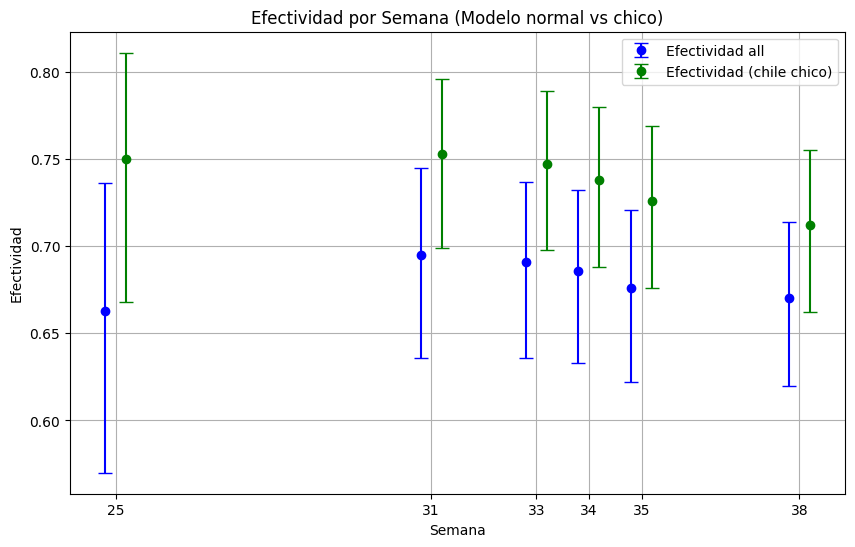

In [9]:
eff_inm_week = []
IC_lower_week = []
IC_upper_week = []

eff_inm_week_chico = []
IC_lower_week_chico = []
IC_upper_week_chico = []

semana = [25, 31, 33, 34, 35, 38]

for i in semana:
    summary_df = dict_resul_week[f'cox_model_week_{i}'].copy().reset_index()
    summary_df_chico = dict_resul_week[f'cox_model_week_{i}_chico'].copy().reset_index()
    
    eff_inm_week_app = summary_df.loc[summary_df['covariate'] == 'inmunizado', 'effectiveness'].values[0]
    IC_lower_week_app = summary_df.loc[summary_df['covariate'] == 'inmunizado', 'eff_lower_95'].values[0]
    IC_upper_week_app = summary_df.loc[summary_df['covariate'] == 'inmunizado', 'eff_upper_95'].values[0]
    
    eff_inm_week_chico_app = summary_df_chico.loc[summary_df_chico['covariate'] == 'inmunizado', 'effectiveness'].values[0]
    IC_lower_week_chico_app = summary_df_chico.loc[summary_df_chico['covariate'] == 'inmunizado', 'eff_lower_95'].values[0]
    IC_upper_week_chico_app = summary_df_chico.loc[summary_df_chico['covariate'] == 'inmunizado', 'eff_upper_95'].values[0]
    
    eff_inm_week.append(eff_inm_week_app)    
    IC_lower_week.append(IC_lower_week_app)
    IC_upper_week.append(IC_upper_week_app)
    
    eff_inm_week_chico.append(eff_inm_week_chico_app)    
    IC_lower_week_chico.append(IC_lower_week_chico_app)
    IC_upper_week_chico.append(IC_upper_week_chico_app)
    
df_normal = pd.DataFrame({
    'semana': semana,
    'inmunizado': eff_inm_week,
    'IC_lower': IC_lower_week,
    'IC_upper': IC_upper_week
})

df_chico = pd.DataFrame({
    'semana': semana,
    'inmunizado': eff_inm_week_chico,
    'IC_lower': IC_lower_week_chico,
    'IC_upper': IC_upper_week_chico
})

# Calcular el error para ambos DataFrames
df_normal['error_lower'] = df_normal['inmunizado'] - df_normal['IC_lower']
df_normal['error_upper'] = df_normal['IC_upper'] - df_normal['inmunizado']

df_chico['error_lower'] = df_chico['inmunizado'] - df_chico['IC_lower']
df_chico['error_upper'] = df_chico['IC_upper'] - df_chico['inmunizado']

plt.figure(figsize=(10, 6))

x_offset = 0.2
semana_normal = np.array(df_normal['semana']) - x_offset
semana_chico = np.array(df_chico['semana']) + x_offset

# Modelo normal (desplazado a la izquierda)
plt.errorbar(semana_normal, df_normal['inmunizado'], 
             yerr=[df_normal['error_lower'], df_normal['error_upper']], 
             fmt='o', capsize=5, label='Efectividad all', color='blue')

# Modelo _chico (desplazado a la derecha)
plt.errorbar(semana_chico, df_chico['inmunizado'], 
             yerr=[df_chico['error_lower'], df_chico['error_upper']], 
             fmt='o', capsize=5, label='Efectividad (chile chico)', color='green')

# Etiquetas y título
plt.xlabel('Semana')
plt.ylabel('Efectividad')
plt.title('Efectividad por Semana (Modelo normal vs chico)')
plt.xticks(df_normal['semana'])  # Para mostrar los valores originales de la semana en el eje x
plt.grid(True)
plt.legend()

# Mostrar el gráfico
plt.show()